In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import date
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [34]:
DATA_PATH    = 'EasyVisa.csv'
TARGET_COL   = 'case_status'
PROBLEM_TYPE = 'classification'

COLS_TO_DROP = ['case_id']         

BINARY_YN_COLS = [
    'has_job_experience',
    'requires_job_training',
    'full_time_position'
]
BINARY_MAP = {'Y': 1, 'N': 0}

ORDINAL_COLS = {
    'education_of_employee': ['High School', "Bachelor's", "Master's", 'Doctorate']
}

ONEHOT_COLS = ['continent', 'region_of_employment']

TRANSFORM_COLS = ['no_of_employees', 'prevailing_wage_annual']

WINSORIZE_COLS  = ['no_of_employees', 'prevailing_wage_annual']
WINSORIZE_LOWER = 0.01
WINSORIZE_UPPER = 0.99

IMPUTE_MEDIAN = []   # EDA confirmed: no missing values in this dataset
IMPUTE_MEAN   = []
IMPUTE_MODE   = []

In [7]:
df=pd.read_csv(DATA_PATH)

In [8]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [9]:
df.shape

(25480, 12)

---
## Drop Useless Columns


In [10]:
# Drop columns
if COLS_TO_DROP:
    df.drop(columns=COLS_TO_DROP,inplace=True)
    print("Dropped columns:", COLS_TO_DROP)

# Check constant columns
const_cols = [col for col in df.columns if df[col].nunique() <= 1]

if const_cols:
    print("Constant columns:", const_cols)
else:
    print("No constant columns")


Dropped columns: ['case_id']
No constant columns


In [11]:
print("Shape:", df.shape)

Shape: (25480, 11)


---
##Handle Missing Values


In [12]:
# Median imputation
if IMPUTE_MEDIAN:
    for col in IMPUTE_MEDIAN:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(col, ": filled with median =", round(median_val, 4))

# Mean imputation
if IMPUTE_MEAN:
    for col in IMPUTE_MEAN:
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)
        print(col, ": filled with mean =", round(mean_val, 4))

# Mode imputation
if IMPUTE_MODE:
    for col in IMPUTE_MODE:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(col, ": filled with mode =", mode_val)

# Check remaining missing values
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("\nNo missing values left")
else:
    print("\nMissing values still present:")
    print(remaining)


No missing values left


---
## Fix Data Quality Issues
**EDA Findings to fix:**
1. `no_of_employees` has negative values (min = -26) — physically impossible for a company
2. `prevailing_wage` is in mixed units (Hour / Week / Month / Year) — values are not comparable as-is

Both must be fixed before any transformation or encoding.

In [13]:
# Check before fix
(df['no_of_employees']<0.).sum()

np.int64(33)

In [14]:
# Fix negative values
df["no_of_employees"] = df["no_of_employees"].abs()

In [16]:
# Check after fix
(df['no_of_employees']<0.).sum()

np.int64(0)

In [17]:
# 4.2 Normalize prevailing_wage to annual salary
# Hour  x 2080 = Annual  (52 weeks x 40 hours)
# Week  x 52   = Annual
# Month x 12   = Annual
# Year  x 1    = Already Annual

wage_multiplier = {
    'Hour': 2080,
    'Week': 52,
    'Month': 12,
    'Year': 1
}

df['prevailing_wage_annual'] = df['prevailing_wage'] * df['unit_of_wage'].map(wage_multiplier)


In [19]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_annual
0,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,1231782.03
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,83425.65
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,122996.86
3,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,83434.03
4,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,149907.39


In [20]:
# 4.3 Drop original wage columns — replaced by prevailing_wage_annual
df.drop(columns=['prevailing_wage', 'unit_of_wage'], inplace=True)

In [21]:
df.shape

(25480, 10)

---
## Feature Engineering — Create New Features


In [23]:
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [24]:
current_year

2026

**Subtract current year with year of estab to get company's age**

In [25]:
df['company_age'] = current_year-df['yr_of_estab']

In [26]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,2007,West,Y,Denied,1231782.03,19
1,Asia,Master's,Y,N,2412,2002,Northeast,Y,Certified,83425.65,24
2,Asia,Bachelor's,N,Y,44444,2008,West,Y,Denied,122996.86,18
3,Asia,Bachelor's,N,N,98,1897,West,Y,Denied,83434.03,129
4,Africa,Master's,Y,N,1082,2005,South,Y,Certified,149907.39,21


In [27]:
# 5.2 Drop yr_of_estab — replaced by company_age
df.drop(columns=['yr_of_estab'], inplace=True)

In [28]:
df.shape

(25480, 10)

### Split X and Y

In [29]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [30]:
X

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,West,Y,1231782.03,19
1,Asia,Master's,Y,N,2412,Northeast,Y,83425.65,24
2,Asia,Bachelor's,N,Y,44444,West,Y,122996.86,18
3,Asia,Bachelor's,N,N,98,West,Y,83434.03,129
4,Africa,Master's,Y,N,1082,South,Y,149907.39,21
...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,South,Y,77092.57,18
25476,Asia,High School,Y,N,3274,Northeast,Y,279174.79,20
25477,Asia,Master's,Y,N,1121,South,N,146298.85,116
25478,Asia,Master's,Y,Y,1918,West,Y,86154.77,139


In [31]:
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

**Manual encoding target column**

In [32]:
y=np.where(y=='Denied',1,0)

In [33]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

In [37]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,West,Y,Denied,1231782.03,19
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,83425.65,24
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,122996.86,18
3,Asia,Bachelor's,N,N,98,West,Y,Denied,83434.03,129
4,Africa,Master's,Y,N,1082,South,Y,Certified,149907.39,21


## Feature Transformation

In [35]:
numerical_features   = [col for col in df.columns if df[col].dtype != 'O']
categorical_features = [col for col in df.columns if df[col].dtype == 'O']

In [39]:
discrete_features    = [col for col in numerical_features if df[col].nunique() <= 25]
continuous_features  = [col for col in numerical_features if df[col].nunique() >  25]

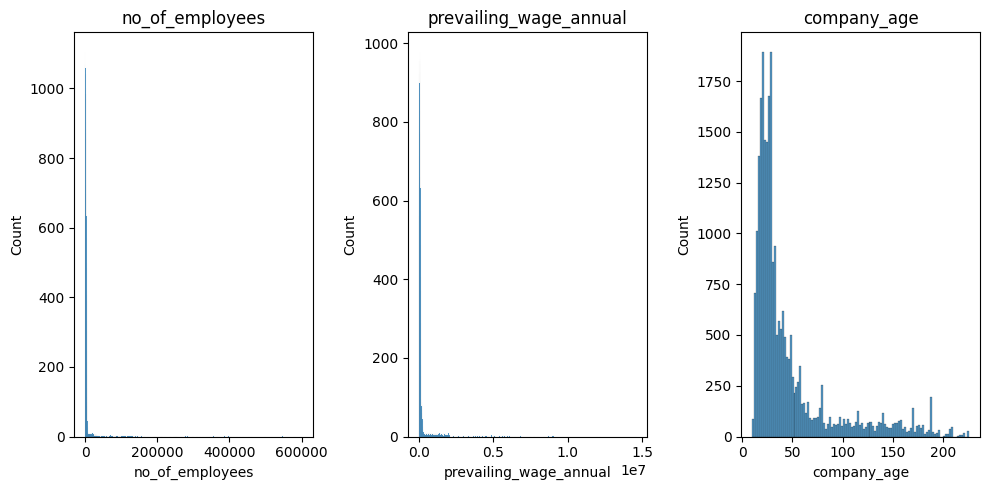

In [38]:
plt.figure(figsize=(10, 5))

cols = ['no_of_employees', 'prevailing_wage_annual', 'company_age']

for i, col in enumerate(cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [40]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees          12.27
prevailing_wage_annual    8.98
company_age               2.04
dtype: float64

### train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
print(X_train.shape,X_test.shape)

(20384, 9) (5096, 9)


In [45]:
X_train

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,prevailing_wage_annual,company_age
2403,Asia,High School,Y,Y,1411,West,Y,75107.37,17
6830,North America,Master's,Y,N,781,West,Y,102403.56,14
878,Asia,High School,Y,N,958,South,Y,89991.95,21
24061,Asia,Master's,N,N,900,West,Y,128104.61,64
2109,Europe,High School,N,N,3533,West,Y,12647.14,33
...,...,...,...,...,...,...,...,...,...
21575,North America,Master's,Y,N,4196,Midwest,N,110878.38,16
5390,Asia,Master's,Y,N,1915,West,Y,86111.13,13
860,Europe,Master's,N,N,2922,West,Y,96192.58,25
15795,Asia,Master's,Y,N,6155,Northeast,Y,98659.01,15
